# Import Libraries

In [32]:
import numpy as np
import pandas as pd
import mlflow
import mlflow.sklearn
from sklearn.metrics import roc_auc_score, accuracy_score
from sklearn.ensemble import RandomForestClassifier

# Loading the Data and Selecting the Features

### Import Data

In [33]:
loan_data_inputs_train = pd.read_csv('/Users/lindokuhletami/Desktop/Space/basel-credit-risk-model/data/loan_data_inputs_train.csv')
loan_data_targets_train = pd.read_csv('/Users/lindokuhletami/Desktop/Space/basel-credit-risk-model/data/loan_data_targets_train.csv')


### Explore Data

In [34]:
loan_data_inputs_train.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,dti:21.7-22.4,dti:22.4-35,dti:>35,mths_since_last_record:Missing,mths_since_last_record:0-2,mths_since_last_record:3-20,mths_since_last_record:21-31,mths_since_last_record:32-80,mths_since_last_record:81-86,mths_since_last_record:>=86
0,12796369,14818505,24000,24000,24000.0,36 months,8.90,762.08,A,A5,...,1,0,0,1,0,0,0,0,0,0
1,1439740,1691948,10000,10000,10000.0,36 months,14.33,343.39,C,C1,...,0,0,0,1,0,0,0,0,0,0
2,5214749,6556909,20425,20425,20425.0,36 months,8.90,648.56,A,A5,...,0,0,0,1,0,0,0,0,0,0
3,13827698,15890016,17200,17200,17200.0,36 months,16.59,609.73,D,D1,...,0,0,0,1,0,0,0,0,0,0
4,422455,496525,8400,8400,7450.0,36 months,12.84,282.40,C,C2,...,0,1,0,1,0,0,0,0,0,0


In [35]:
loan_data_targets_train.head()

,good_bad
0,1
1,1
2,1
3,0
4,0


In [36]:
loan_data_inputs_train.shape

(373028, 373)

In [37]:
loan_data_targets_train.shape

(373028, 1)

### Selecting the Features

In [38]:
inputs_train_with_ref_cat = loan_data_inputs_train.loc[: , ['grade:A',
'grade:B',
'grade:C',
'grade:D',
'grade:E',
'grade:F',
'grade:G',
'home_ownership:RENT_OTHER_NONE_ANY',
'home_ownership:OWN',
'home_ownership:MORTGAGE',
'addr_state:ND_NE_IA_NV_FL_HI_AL',
'addr_state:NM_VA',
'addr_state:NY',
'addr_state:OK_TN_MO_LA_MD_NC',
'addr_state:CA',
'addr_state:UT_KY_AZ_NJ',
'addr_state:AR_MI_PA_OH_MN',
'addr_state:RI_MA_DE_SD_IN',
'addr_state:GA_WA_OR',
'addr_state:WI_MT',
'addr_state:TX',
'addr_state:IL_CT',
'addr_state:KS_SC_CO_VT_AK_MS',
'addr_state:WV_NH_WY_DC_ME_ID',
'verification_status:Not Verified',
'verification_status:Source Verified',
'verification_status:Verified',
'purpose:educ__sm_b__wedd__ren_en__mov__house',
'purpose:credit_card',
'purpose:debt_consolidation',
'purpose:oth__med__vacation',
'purpose:major_purch__car__home_impr',
'initial_list_status:f',
'initial_list_status:w',
'term:36',
'term:60',
'emp_length:0',
'emp_length:1',
'emp_length:2-4',
'emp_length:5-6',
'emp_length:7-9',
'emp_length:10',
'mths_since_issue_d:<38',
'mths_since_issue_d:38-39',
'mths_since_issue_d:40-41',
'mths_since_issue_d:42-48',
'mths_since_issue_d:49-52',
'mths_since_issue_d:53-64',
'mths_since_issue_d:65-84',
'mths_since_issue_d:>84',
'int_rate:<9.548',
'int_rate:9.548-12.025',
'int_rate:12.025-15.74',
'int_rate:15.74-20.281',
'int_rate:>20.281',
'mths_since_earliest_cr_line:<140',
'mths_since_earliest_cr_line:141-164',
'mths_since_earliest_cr_line:165-247',
'mths_since_earliest_cr_line:248-270',
'mths_since_earliest_cr_line:271-352',
'mths_since_earliest_cr_line:>352',
'delinq_2yrs:0',
'delinq_2yrs:1-3',
'delinq_2yrs:>=4',
'inq_last_6mths:0',
'inq_last_6mths:1-2',
'inq_last_6mths:3-6',
'inq_last_6mths:>6',
'open_acc:0',
'open_acc:1-3',
'open_acc:4-12',
'open_acc:13-17',
'open_acc:18-22',
'open_acc:23-25',
'open_acc:26-30',
'open_acc:>=31',
'pub_rec:0-2',
'pub_rec:3-4',
'pub_rec:>=5',
'total_acc:<=27',
'total_acc:28-51',
'total_acc:>=52',
'acc_now_delinq:0',
'acc_now_delinq:>=1',
'total_rev_hi_lim:<=5K',
'total_rev_hi_lim:5K-10K',
'total_rev_hi_lim:10K-20K',
'total_rev_hi_lim:20K-30K',
'total_rev_hi_lim:30K-40K',
'total_rev_hi_lim:40K-55K',
'total_rev_hi_lim:55K-95K',
'total_rev_hi_lim:>95K',
'annual_inc:<20K',
'annual_inc:20K-30K',
'annual_inc:30K-40K',
'annual_inc:40K-50K',
'annual_inc:50K-60K',
'annual_inc:60K-70K',
'annual_inc:70K-80K',
'annual_inc:80K-90K',
'annual_inc:90K-100K',
'annual_inc:100K-120K',
'annual_inc:120K-140K',
'annual_inc:>140K',
'dti:<=1.4',
'dti:1.4-3.5',
'dti:3.5-7.7',
'dti:7.7-10.5',
'dti:10.5-16.1',
'dti:16.1-20.3',
'dti:20.3-21.7',
'dti:21.7-22.4',
'dti:22.4-35',
'dti:>35',
'mths_since_last_delinq:Missing',
'mths_since_last_delinq:0-3',
'mths_since_last_delinq:4-30',
'mths_since_last_delinq:31-56',
'mths_since_last_delinq:>=57',
'mths_since_last_record:Missing',
'mths_since_last_record:0-2',
'mths_since_last_record:3-20',
'mths_since_last_record:21-31',
'mths_since_last_record:32-80',
'mths_since_last_record:81-86',
'mths_since_last_record:>=86']]

In [39]:
ref_categories = ['grade:G',
'home_ownership:RENT_OTHER_NONE_ANY',
'addr_state:ND_NE_IA_NV_FL_HI_AL',
'verification_status:Verified',
'purpose:educ__sm_b__wedd__ren_en__mov__house',
'initial_list_status:f',
'term:60',
'emp_length:0',
'mths_since_issue_d:>84',
'int_rate:>20.281',
'mths_since_earliest_cr_line:<140',
'delinq_2yrs:>=4',
'inq_last_6mths:>6',
'open_acc:0',
'pub_rec:0-2',
'total_acc:<=27',
'acc_now_delinq:0',
'total_rev_hi_lim:<=5K',
'annual_inc:<20K',
'dti:>35',
'mths_since_last_delinq:0-3',
'mths_since_last_record:0-2']

In [40]:
inputs_train = inputs_train_with_ref_cat.drop(ref_categories, axis = 1)
inputs_train.head()

,grade:A,grade:B,grade:C,grade:D,grade:E,grade:F,home_ownership:OWN,home_ownership:MORTGAGE,addr_state:NM_VA,addr_state:NY,...,mths_since_last_delinq:Missing,mths_since_last_delinq:4-30,mths_since_last_delinq:31-56,mths_since_last_delinq:>=57,mths_since_last_record:Missing,mths_since_last_record:3-20,mths_since_last_record:21-31,mths_since_last_record:32-80,mths_since_last_record:81-86,mths_since_last_record:>=86
0,1.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,...,1,0,0,0,1,0,0,0,0,0
1,0.0,0.0,1.0,0.0,0.0,0.0,0,0,0,0,...,0,1,0,0,1,0,0,0,0,0
2,1.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,...,0,0,1,0,1,0,0,0,0,0
3,0.0,0.0,0.0,1.0,0.0,0.0,0,0,0,0,...,0,1,0,0,1,0,0,0,0,0
4,0.0,0.0,1.0,0.0,0.0,0.0,0,0,0,0,...,1,0,0,0,1,0,0,0,0,0


In [41]:
X = inputs_train.values
y = loan_data_targets_train['good_bad'].values

In [42]:
X

array([[1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 1.]], shape=(373028, 104))

In [43]:
y

array([1, 1, 1, ..., 1, 1, 1], shape=(373028,))

In [60]:
import mlflow
print(mlflow.get_tracking_uri())

sqlite:////Users/lindokuhletami/Desktop/Space/basel-credit-risk-model/src/mlflow.db


In [56]:
mlflow.set_experiment("credit_risk_pd_model")

<Experiment: artifact_location='/Users/lindokuhletami/Desktop/Space/basel-credit-risk-model/src/mlruns/1', creation_time=1773159931125, experiment_id='1', last_update_time=1773159931125, lifecycle_stage='active', name='credit_risk_pd_model', tags={}, workspace='default'>

# PD Model Estimation

## Logistic Regression

In [57]:
from sklearn.linear_model import LogisticRegression
from sklearn import metrics

In [62]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score
import mlflow
import mlflow.sklearn

with mlflow.start_run(run_name="logistic_regression"):

    model = LogisticRegression(max_iter=1000)

    model.fit(X, y)

    # probability predictions
    preds_proba = model.predict_proba(X)[:, 1]

    # class predictions
    preds = model.predict(X)

    # metrics
    auc = roc_auc_score(y, preds_proba)
    precision = precision_score(y, preds)
    recall = recall_score(y, preds)
    f1 = f1_score(y, preds)

    # log parameters
    mlflow.log_param("model_type", "logistic_regression")
    mlflow.log_param("max_iter", 1000)

    # log metrics
    mlflow.log_metric("AUC", auc)
    mlflow.log_metric("precision", precision)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("f1_score", f1)

    # log model
    mlflow.sklearn.log_model(model, "logistic_model")

    print("AUC:", auc)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1:", f1)

2026/03/10 19:35:50 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/10 19:35:50 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


AUC: 0.6948530792415584
Precision: 0.8906987654651958
Recall: 0.9999819413092551
F1: 0.9421820166887623


# Tree based model 

In [63]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score
import mlflow
import mlflow.sklearn

with mlflow.start_run(run_name="random_forest"):

    rf_model = RandomForestClassifier(
        n_estimators=200,
        max_depth=8,
        random_state=42
    )

    rf_model.fit(X, y)

    # probability predictions
    rf_preds_proba = rf_model.predict_proba(X)[:, 1]

    # class predictions
    rf_preds = rf_model.predict(X)

    # metrics
    rf_auc = roc_auc_score(y, rf_preds_proba)
    rf_precision = precision_score(y, rf_preds)
    rf_recall = recall_score(y, rf_preds)
    rf_f1 = f1_score(y, rf_preds)

    # log parameters
    mlflow.log_param("model_type", "random_forest")
    mlflow.log_param("n_estimators", 200)
    mlflow.log_param("max_depth", 8)

    # log metrics
    mlflow.log_metric("AUC", rf_auc)
    mlflow.log_metric("precision", rf_precision)
    mlflow.log_metric("recall", rf_recall)
    mlflow.log_metric("f1_score", rf_f1)

    # log model
    mlflow.sklearn.log_model(rf_model, "rf_model")

    print("Random Forest AUC:", rf_auc)
    print("Precision:", rf_precision)
    print("Recall:", rf_recall)
    print("F1:", rf_f1)

2026/03/10 19:36:43 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/10 19:36:43 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Random Forest AUC: 0.6890576793407354
Precision: 0.8906838092582863
Recall: 1.0
F1: 0.9421816645351195


## Build a Logistic Regression Model with P-Values

In [ ]:
from sklearn import linear_model
import scipy.stats as stat
import numpy as np

class LogisticRegression_with_p_values:

    def __init__(self, *args, **kwargs):
        self.model = linear_model.LogisticRegression(*args, **kwargs)

    def fit(self, X, y):
        # arrayify / float
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float)

        # drop any constant columns (zero variance) – optional but helpful
        var = X.var(axis=0)
        if (var == 0).any():
            const_idx = np.where(var == 0)[0]
            # you could also remember names of removed columns here
            # print(f"dropping constant columns {const_idx}")
            X = X[:, var > 0]

        self.model.fit(X, y)

        denom = 2.0 * (1.0 + np.cosh(self.model.decision_function(X)))
        denom = np.tile(denom, (X.shape[1], 1)).T
        F_ij = np.dot((X / denom).T, X).astype(float)

        # invert – if singular, fall back to pseudo‑inverse
        try:
            Cramer_Rao = np.linalg.inv(F_ij)
        except np.linalg.LinAlgError:
            # print("information matrix singular; using pseudo‑inverse")
            Cramer_Rao = np.linalg.pinv(F_ij)

        sigma_estimates = np.sqrt(np.diagonal(Cramer_Rao))

        z_scores = self.model.coef_[0] / sigma_estimates
        p_values = [stat.norm.sf(abs(z)) * 2 for z in z_scores]

        self.coef_ = self.model.coef_
        self.intercept_ = self.model.intercept_
        self.p_values = p_values

In [ ]:
reg2 = LogisticRegression_with_p_values()

In [ ]:
reg2.fit(inputs_train, loan_data_targets_train)

/Users/lindokuhletami/Desktop/Space/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [ ]:
# after reg.fit(inputs_train, loan_data_targets_train) …
# make sure the number of coefficients matches the number of columns
print("shape inputs_train:", inputs_train.shape)
print("coef shape        :", reg.coef_.shape)

coefs = reg2.coef_.ravel()               # shape (n_features,)
names = inputs_train.columns[: coefs.size]   # slice in case of mismatch

# build table in one go
summary_table = pd.DataFrame({
    "Feature name": names,
    "Coefficients": coefs
})
summary_table.index = range(1, len(summary_table) + 1)
summary_table.loc[0] = ["Intercept", reg2.intercept_[0]]
summary_table.sort_index(inplace=True)

# show it – using display avoids the “outputs collapsed” warning
from IPython.display import display
display(summary_table)

shape inputs_train: (373028, 104)
coef shape        : (1, 104)


,Feature name,Coefficients
0,Intercept,-0.247667
1,grade:A,0.960472
2,grade:B,0.733834
3,grade:C,0.542873
4,grade:D,0.360119
5,grade:E,0.205587
6,grade:F,0.027166
7,home_ownership:OWN,0.286076
8,home_ownership:MORTGAGE,0.181805
9,addr_state:NM_VA,0.193967


In [ ]:
p_values = reg2.p_values

In [ ]:
p_values = np.append(np.nan, np.array(p_values))

In [ ]:
summary_table['p_values'] = p_values

In [ ]:
summary_table

,Feature name,Coefficients,p_values
0,Intercept,-0.247667,NaN
1,grade:A,0.960472,1.131274e-25
2,grade:B,0.733834,1.967744e-32
3,grade:C,0.542873,3.844737e-21
4,grade:D,0.360119,4.691521e-11
5,grade:E,0.205587,2.814658e-05
6,grade:F,0.027166,5.951194e-01
7,home_ownership:OWN,0.286076,1.388833e-23
8,home_ownership:MORTGAGE,0.181805,4.958828e-12
9,addr_state:NM_VA,0.193967,5.912254e-10


# Cross Validation for threshold selection
    I am not very sure about this as it would mean that we reject some good loan applicants, so business can advise as to what the best threshold would be to be profitable


OPTIMIZING THRESHOLD VIA CROSS-VALIDATION

Class distribution in training data:
  Class 0: 40778 samples (10.93%)
  Class 1: 332250 samples (89.07%)

CV predictions shape: (373028, 2)

Optimal threshold (based on F1 score): 0.50
F1 score at optimal threshold: 0.9422
Precision at optimal threshold: 0.8907
Recall at optimal threshold: 1.0000
Accuracy at optimal threshold: 0.8907

Optimal threshold (based on Accuracy): 0.50
Accuracy at optimal threshold: 0.8907


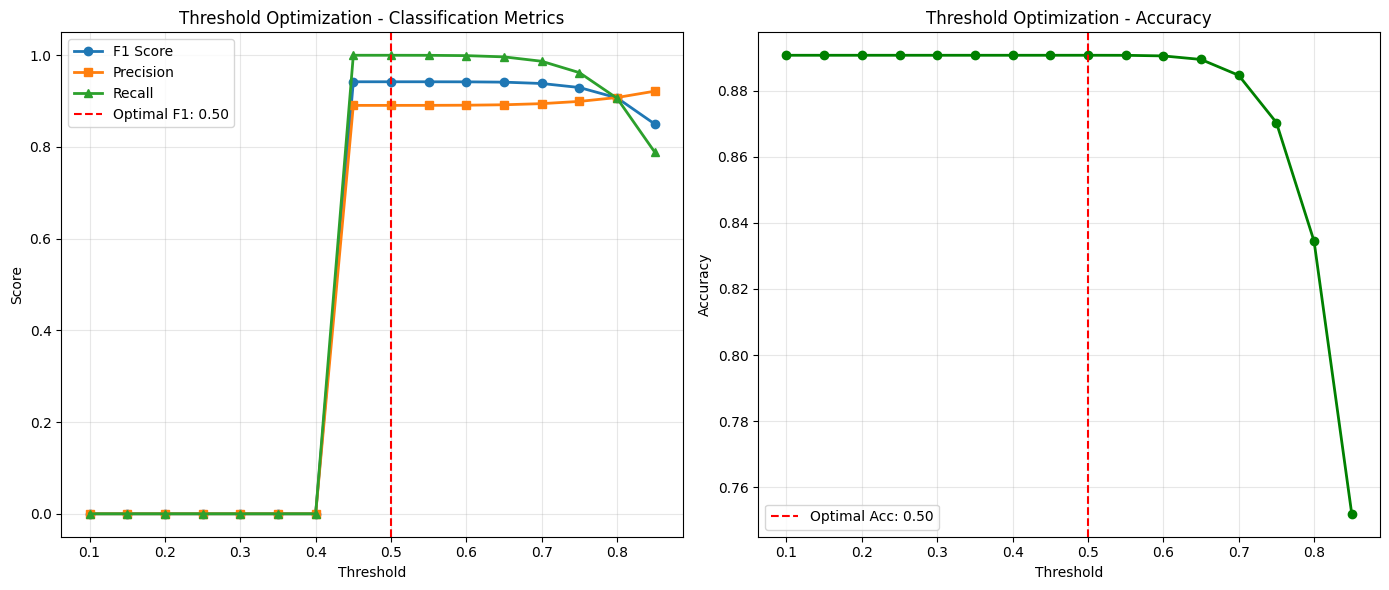

In [ ]:

from sklearn.model_selection import cross_val_predict, KFold, StratifiedKFold
from sklearn.metrics import f1_score, precision_score, recall_score
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


print("\n" + "="*50)
print("OPTIMIZING THRESHOLD VIA CROSS-VALIDATION")
print("="*50)

# Make sure targets are properly shaped (1D array)
if isinstance(loan_data_targets_train, pd.DataFrame):
    y_train = loan_data_targets_train.values.ravel()
else:
    y_train = np.array(loan_data_targets_train).ravel()

# Check class distribution
unique_classes, class_counts = np.unique(y_train, return_counts=True)
print(f"\nClass distribution in training data:")
for cls, count in zip(unique_classes, class_counts):
    print(f"  Class {cls}: {count} samples ({count/len(y_train)*100:.2f}%)")

# Use StratifiedKFold to maintain class distribution in each fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Get cross-validated predictions on training data
try:
    # Get probability predictions
    y_train_proba_cv = cross_val_predict(
        reg2.model,  # or reg2 if it's your custom class
        inputs_train, 
        y_train, 
        cv=cv, 
        method='predict_proba'
    )
    
    # Check the shape of predictions
    print(f"\nCV predictions shape: {y_train_proba_cv.shape}")
    
    # If binary classification, extract positive class probabilities
    if y_train_proba_cv.shape[1] == 2:
        y_train_proba_cv = y_train_proba_cv[:, 1]
    elif y_train_proba_cv.shape[1] == 1:
        # If only one column, it might be predicting only one class
        print("Warning: Model only predicting one class. Using predictions as is.")
        y_train_proba_cv = y_train_proba_cv.ravel()
    else:
        print(f"Unexpected shape: {y_train_proba_cv.shape}")
        
except Exception as e:
    print(f"Error in cross_val_predict: {e}")
    print("Falling back to manual CV...")
    
    # Manual cross-validation as fallback
    y_train_proba_cv = np.zeros(len(y_train))
    
    for train_idx, val_idx in cv.split(inputs_train, y_train):
        X_train_fold, X_val_fold = inputs_train.iloc[train_idx], inputs_train.iloc[val_idx]
        y_train_fold, y_val_fold = y_train[train_idx], y_train[val_idx]
        
        # Train on fold
        reg2.model.fit(X_train_fold, y_train_fold)
        
        # Predict on validation fold
        fold_proba = reg2.model.predict_proba(X_val_fold)
        
        # Handle binary case
        if fold_proba.shape[1] == 2:
            y_train_proba_cv[val_idx] = fold_proba[:, 1]
        else:
            y_train_proba_cv[val_idx] = fold_proba.ravel()
    
    print("Manual CV completed")

# Test different thresholds
thresholds = np.arange(0.1, 0.9, 0.05)
f1_scores = []
precision_scores = []
recall_scores = []
accuracy_scores = []

for threshold in thresholds:
    y_pred_cv = (y_train_proba_cv > threshold).astype(int)
    
    # Check if we have both classes in predictions
    if len(np.unique(y_pred_cv)) == 2:
        f1_scores.append(f1_score(y_train, y_pred_cv))
        precision_scores.append(precision_score(y_train, y_pred_cv))
        recall_scores.append(recall_score(y_train, y_pred_cv))
    else:
        # If only one class predicted, set scores to 0
        f1_scores.append(0)
        precision_scores.append(0)
        recall_scores.append(0)
    
    accuracy_scores.append(np.mean(y_pred_cv == y_train))

# Find optimal threshold for different metrics
optimal_idx_f1 = np.argmax(f1_scores)
optimal_threshold_f1 = thresholds[optimal_idx_f1]

optimal_idx_acc = np.argmax(accuracy_scores)
optimal_threshold_acc = thresholds[optimal_idx_acc]

print(f"\nOptimal threshold (based on F1 score): {optimal_threshold_f1:.2f}")
print(f"F1 score at optimal threshold: {f1_scores[optimal_idx_f1]:.4f}")
print(f"Precision at optimal threshold: {precision_scores[optimal_idx_f1]:.4f}")
print(f"Recall at optimal threshold: {recall_scores[optimal_idx_f1]:.4f}")
print(f"Accuracy at optimal threshold: {accuracy_scores[optimal_idx_f1]:.4f}")

print(f"\nOptimal threshold (based on Accuracy): {optimal_threshold_acc:.2f}")
print(f"Accuracy at optimal threshold: {accuracy_scores[optimal_idx_acc]:.4f}")

# Plot threshold optimization
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(thresholds, f1_scores, marker='o', label='F1 Score', linewidth=2)
plt.plot(thresholds, precision_scores, marker='s', label='Precision', linewidth=2)
plt.plot(thresholds, recall_scores, marker='^', label='Recall', linewidth=2)
plt.axvline(x=optimal_threshold_f1, color='r', linestyle='--', 
            label=f'Optimal F1: {optimal_threshold_f1:.2f}')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Threshold Optimization - Classification Metrics')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(thresholds, accuracy_scores, marker='o', color='green', linewidth=2)
plt.axvline(x=optimal_threshold_acc, color='r', linestyle='--', 
            label=f'Optimal Acc: {optimal_threshold_acc:.2f}')
plt.xlabel('Threshold')
plt.ylabel('Accuracy')
plt.title('Threshold Optimization - Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
import pickle

save_path = "/Users/lindokuhletami/Desktop/Space/basel-credit-risk-model/src/pd_model.sav"

# Save ONLY the sklearn model
model_to_save = reg2.model

with open(save_path, "wb") as f:
    pickle.dump(model_to_save, f)

print(f"Model successfully saved to: {save_path}")

Model successfully saved to: /Users/lindokuhletami/Desktop/Space/basel-credit-risk-model/src/pd_model.sav
